# Scaling sensitivity — Reward 1: Asymmetric Quadratic

**Reward:** $R_h(x,a) = -(x-a)^2 \cdot (1+|x|) + \mathcal{N}(0,0.01)$  
**Optimal action:** $a^*(x) = x$  (growth order $m=1$)  
**Action space:** $[-5, 5]$ — optimal always in interior  

This notebook sweeps `scaling` (the UCB exploration constant) to find the value
that best balances exploration and exploitation for this reward.

Sections:
1. Sweep over 10 scaling values — summary table
2. Performance vs scaling (log-scale)
3. Partition growth vs scaling
4. Performance vs complexity scatter
5. Learning curves for three representative scaling values
6. Partition growth curves

**To adapt for another reward:** edit the `# ── EDIT HERE ──` block in Cell 1 only.

## Cell 1 — Configuration  *(edit here)*

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from joblib import Parallel, delayed

import aaro_again as a

# ╔══════════════════════════════════════════════════════════════════════╗
# ║                        EDIT HERE                                    ║
# ╠══════════════════════════════════════════════════════════════════════╣
# ║  Swap REWARD_FN and adjust INITIAL_Q to change the experiment.      ║
# ║  Everything else updates automatically.                             ║
# ║                                                                     ║
# ║  Reward options:                                                    ║
# ║    a.reward_quadratic_asymmetric  -(x-a)²·(1+|x|)  initial_q=100   ║
# ║    a.reward_quadratic_shifted     -(x-a-0.5)²      initial_q=1837  ║
# ║    a.reward_quartic               -(x-a)⁴          initial_q=100   ║
# ║    a.reward_6_1                   -(x-a)²          initial_q=100   ║
# ╚══════════════════════════════════════════════════════════════════════╝

REWARD_FN  = a.reward_quadratic_asymmetric
INITIAL_Q  = 100.0     # 100 for asymmetric/quartic; 1837.1 for shifted/6_1
ACTION_LO  = -5.0
ACTION_HI  =  5.0
N_EPS      = 2000
N_SEEDS    = 10
ALPHA      = 0.5       # UCB exponent: bonus = scaling / n^alpha

# Scaling values to sweep
SCALINGS = [0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50, 100, 500]

# Three representative values for the learning curve plots
CHOSEN_SCALINGS = [0.1, 5, 100]

print(f'Reward      : {REWARD_FN.__name__}')
print(f'Action space: [{ACTION_LO}, {ACTION_HI}]')
print(f'initial_q   : {INITIAL_Q}')
print(f'N_EPS={N_EPS}, N_SEEDS={N_SEEDS}')
print(f'Scalings    : {SCALINGS}')


Reward      : reward_quadratic_asymmetric
Action space: [-5.0, 5.0]
initial_q   : 100.0
N_EPS=2000, N_SEEDS=10
Scalings    : [0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50, 100, 500]


## Cell 2 — Scaling sweep

In [2]:
configs = [
    a.ExpConfig(
        starting_state = 4.0,
        action_lo      = ACTION_LO,
        action_hi      = ACTION_HI,
        initial_q      = INITIAL_Q,
        rho            = 10.0,
        reward_step_fn = REWARD_FN,
        label          = f'scaling={s}',
        scaling        = s,
        alpha          = ALPHA,
        nEps           = N_EPS,
        n_seeds        = N_SEEDS,
    )
    for s in SCALINGS
]

results_sweep = a.run_experiment(configs, n_jobs=-1)


  Running: scaling=0.01 ...
    Done. Final mean VPI (last 100 ep): -62.491
  Running: scaling=0.05 ...
    Done. Final mean VPI (last 100 ep): -54.970
  Running: scaling=0.1 ...
    Done. Final mean VPI (last 100 ep): -52.040
  Running: scaling=0.5 ...
    Done. Final mean VPI (last 100 ep): -52.507
  Running: scaling=1 ...
    Done. Final mean VPI (last 100 ep): -47.762
  Running: scaling=5 ...
    Done. Final mean VPI (last 100 ep): -127.879
  Running: scaling=10 ...
    Done. Final mean VPI (last 100 ep): -141.184
  Running: scaling=50 ...
    Done. Final mean VPI (last 100 ep): -165.424
  Running: scaling=100 ...
    Done. Final mean VPI (last 100 ep): -165.579
  Running: scaling=500 ...
    Done. Final mean VPI (last 100 ep): -164.930


## Cell 3 — Summary table

In [3]:
summary = []
for s in SCALINGS:
    label = f'scaling={s}'
    vpi   = results_sweep[label]['vpi']
    arms  = results_sweep[label]['arms']
    summary.append({
        'scaling':           s,
        'final_cum_reward':  np.sum(vpi),
        'late_mean_reward':  np.mean(vpi[-100:]),
        'final_arms':        arms[-1],
        'mean_arms_last100': np.mean(arms[-100:]),
    })

summary_df = pd.DataFrame(summary)
summary_df


,scaling,final_cum_reward,late_mean_reward,final_arms,mean_arms_last100
0,0.01,-134301.458786,-62.491146,12971.9,12799.436
1,0.05,-120038.949251,-54.969511,13233.8,13083.368
2,0.10,-109768.582583,-52.039897,12275.3,12126.194
3,0.50,-114444.623469,-52.506793,12365.0,12212.930
4,1.00,-102733.157679,-47.761931,11384.9,11249.273
5,5.00,-254958.873577,-127.879131,744.2,743.963
6,10.00,-282606.390250,-141.184191,305.6,305.093
7,50.00,-330763.664882,-165.423828,10365.8,10243.364
8,100.00,-330872.807803,-165.578544,4892.9,4876.886
9,500.00,-330741.691297,-164.929866,5633.9,5612.654


## Cell 4 — Performance vs scaling

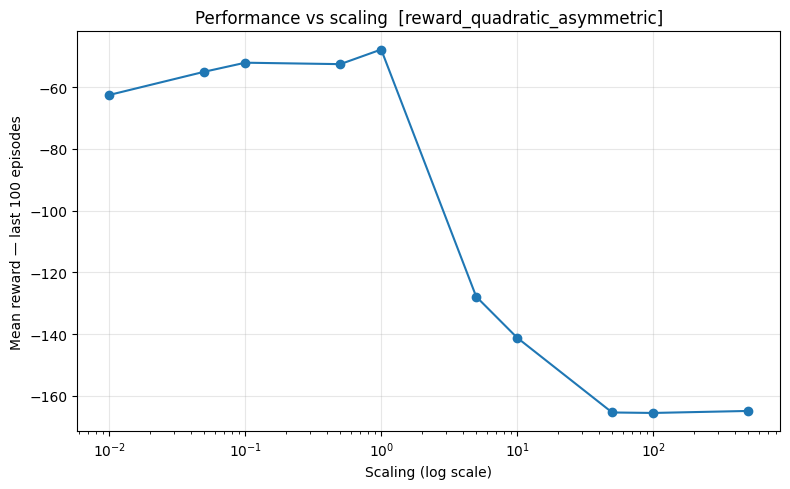

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(summary_df['scaling'], summary_df['late_mean_reward'], marker='o')
ax.set_xscale('log')
ax.set_xlabel('Scaling (log scale)')
ax.set_ylabel('Mean reward — last 100 episodes')
ax.set_title(f'Performance vs scaling  [{REWARD_FN.__name__}]')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Cell 5 — Partition growth vs scaling

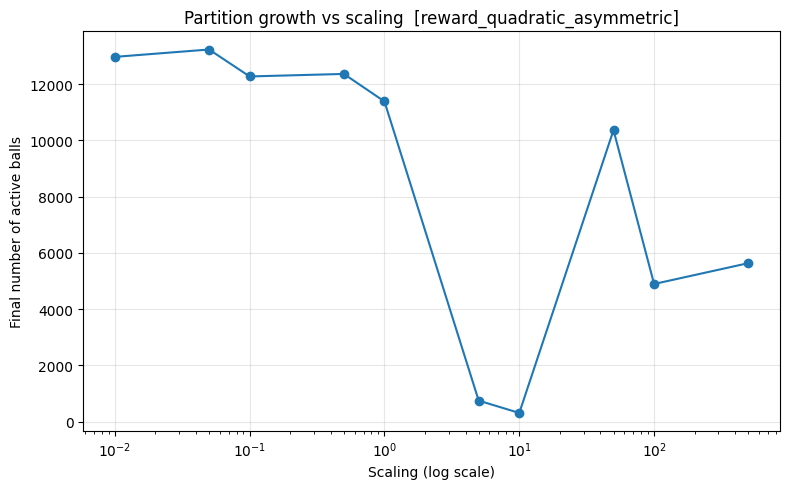

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(summary_df['scaling'], summary_df['final_arms'], marker='o')
ax.set_xscale('log')
ax.set_xlabel('Scaling (log scale)')
ax.set_ylabel('Final number of active balls')
ax.set_title(f'Partition growth vs scaling  [{REWARD_FN.__name__}]')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Cell 6 — Performance vs complexity

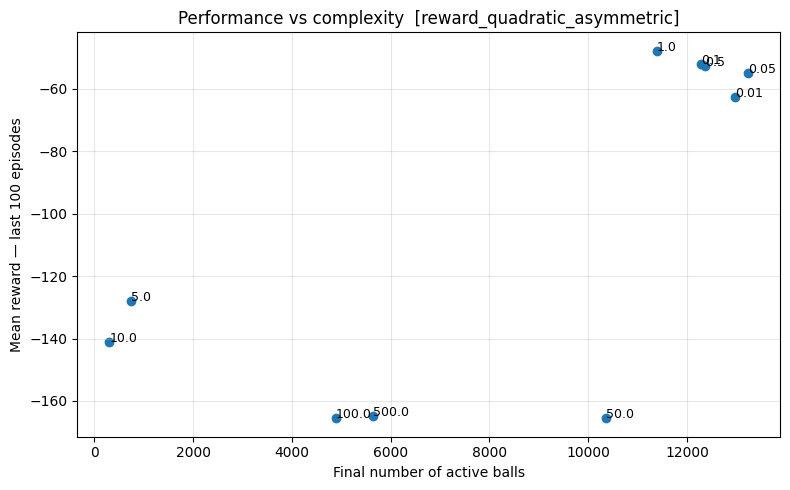

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(summary_df['final_arms'], summary_df['late_mean_reward'])
for _, row in summary_df.iterrows():
    ax.annotate(str(row['scaling']),
                (row['final_arms'], row['late_mean_reward']),
                fontsize=9)
ax.set_xlabel('Final number of active balls')
ax.set_ylabel('Mean reward — last 100 episodes')
ax.set_title(f'Performance vs complexity  [{REWARD_FN.__name__}]')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Cell 7 — Learning curves for representative scaling values

Runs the three `CHOSEN_SCALINGS` values and plots learning curves.

  Running: scaling=0.1 ...
    Done. Final mean VPI (last 100 ep): -59.186
  Running: scaling=5 ...
    Done. Final mean VPI (last 100 ep): -131.730
  Running: scaling=100 ...
    Done. Final mean VPI (last 100 ep): -165.261


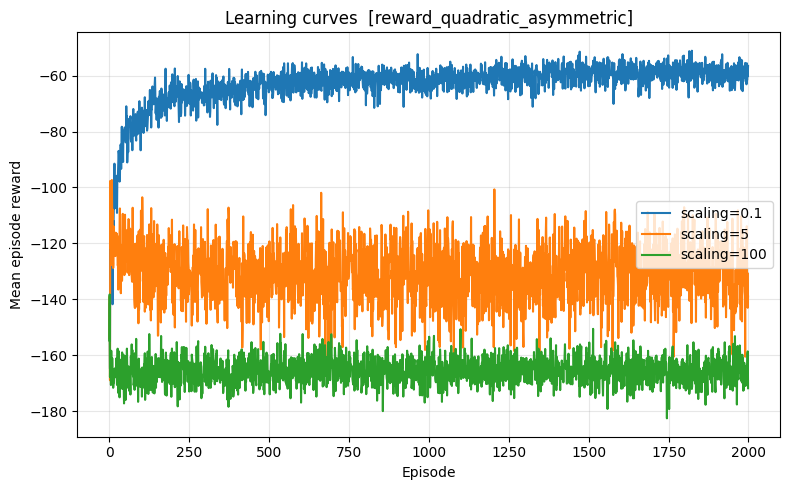

In [7]:
configs_chosen = [
    a.ExpConfig(
        starting_state = 4.0,
        action_lo      = ACTION_LO,
        action_hi      = ACTION_HI,
        initial_q      = INITIAL_Q,
        rho            = 10.0,
        reward_step_fn = REWARD_FN,
        label          = f'scaling={s}',
        scaling        = s,
        alpha          = ALPHA,
        nEps           = N_EPS,
        n_seeds        = N_SEEDS,
    )
    for s in CHOSEN_SCALINGS
]

results_chosen = a.run_experiment(configs_chosen, n_jobs=-1)

fig, ax = plt.subplots(figsize=(8, 5))
for s in CHOSEN_SCALINGS:
    label = f'scaling={s}'
    ax.plot(results_chosen[label]['vpi'], label=label)
ax.set_xlabel('Episode')
ax.set_ylabel('Mean episode reward')
ax.set_title(f'Learning curves  [{REWARD_FN.__name__}]')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Cell 8 — Partition growth over episodes

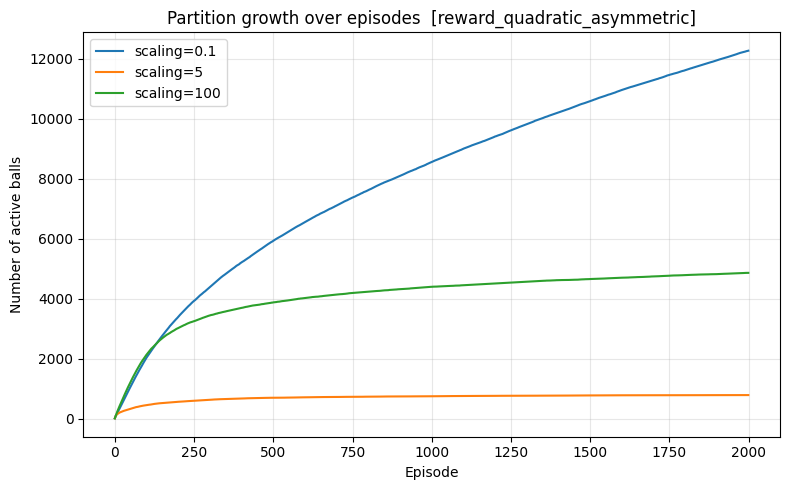

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
for s in CHOSEN_SCALINGS:
    label = f'scaling={s}'
    ax.plot(results_chosen[label]['arms'], label=label)
ax.set_xlabel('Episode')
ax.set_ylabel('Number of active balls')
ax.set_title(f'Partition growth over episodes  [{REWARD_FN.__name__}]')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
